In [1]:
import numpy as np

In [2]:
class AdalineGD:
    def __init__(self, eta = 0.01, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        # Initialize parameters
        seed = np.random.RandomState(self.random_state)
        self.w = seed.normal(loc = 0.0, scale = 0.01, size = X.shape[1])

        self.b = np.float64(0.0)
        self.losses = []

        for i in range(self.n_iter):
            estimated = self.net_input(X)
            error = y - estimated
            delta_w = 2 * self.eta * np.dot(X.T, error) / X.shape[0]
            delta_b = 2 * self.eta * sum(error) / X.shape[0]

            self.w += delta_w
            self.b += delta_b

            loss = (error**2).mean()
            self.losses.append(loss)
        return self




    def net_input(self, X):
        return np.dot(X, self.w) + self.b
    
    def activation(self, X):
        return X
    
    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [3]:
import os
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/'\
    'machine-learning-databases/iris/iris.data'

print(s)

df = pd.read_csv(s, header = None, encoding = 'utf-8')

import matplotlib.pyplot as plt

y = df.iloc[0:100, 4] # 행 0 ~ 99, 5번째 column
y = np.where(y == "Iris-setosa", 0, 1) # setosa -> 0, versicolor -> 1
X = df.iloc[0:100, [0, 2]].values

https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


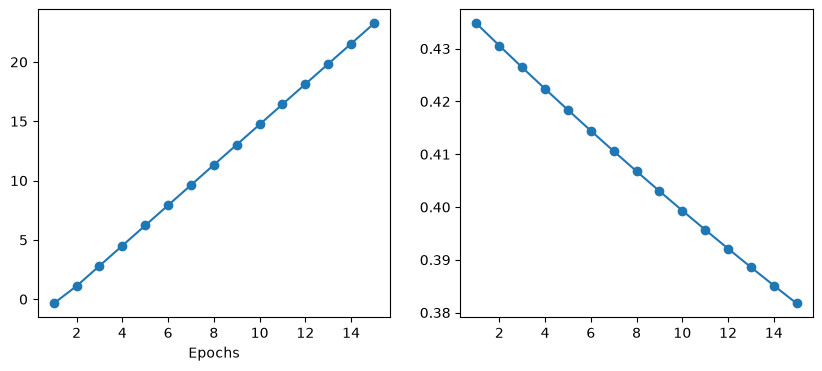

In [7]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))
ada1 = AdalineGD(n_iter = 15, eta = 0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.losses) + 1),  np.log10(ada1.losses), marker = 'o')
ax[0].set_xlabel("Epochs")

ada2 = AdalineGD(n_iter = 15, eta = 0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.losses) + 1), ada2.losses, marker = 'o')